Блок 1. Заголовок

In [ ]:
# CP1 — MAGIC Gamma Telescope
## EDA, preprocessing and baseline models

Блок 2. Импорты

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

Блок 3. Названия колонок

In [ ]:
columns = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1",
    "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"
]

Блок 4. Загрузка данных

In [ ]:
df = pd.read_csv("magic04.data", header=None, names=columns)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


Блок 5. Первичный анализ

In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nClass distribution:")
print(df["class"].value_counts())

Shape: (19020, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB
None

Missing values:
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64

Duplicates: 115

Class distribution:
class
g    12332
h     6688
Name: count, dtype: int64


In [ ]:
df = df.drop_duplicates()

Удаление дубликатов(сверху)

In [ ]:
print("After removing duplicates:", df.shape)

After removing duplicates: (18905, 11)


In [ ]:
df.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000
mean,53.161416,22.145872,2.824643,0.380247,0.214560,-4.177867,10.618826,0.259364,27.551644,193.712554
std,42.259789,18.300664,0.472377,0.182709,0.110384,59.010059,50.900687,20.775268,26.083055,74.685712
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
25%,24.359700,11.874200,2.477100,0.235800,0.128500,-20.479100,-12.769300,-10.835800,5.516400,142.269000
50%,37.129500,17.143800,2.740000,0.354000,0.196400,4.062900,15.338000,0.750000,17.533000,191.832000
75%,69.975400,24.712400,3.101100,0.503500,0.285000,24.133500,35.869400,10.948900,45.704000,240.409000
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000


Блок 6. Кодирование таргета

In [ ]:
df["class"] = df["class"].map({"g": 1, "h": 0})
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


Блок 7. Визуализации

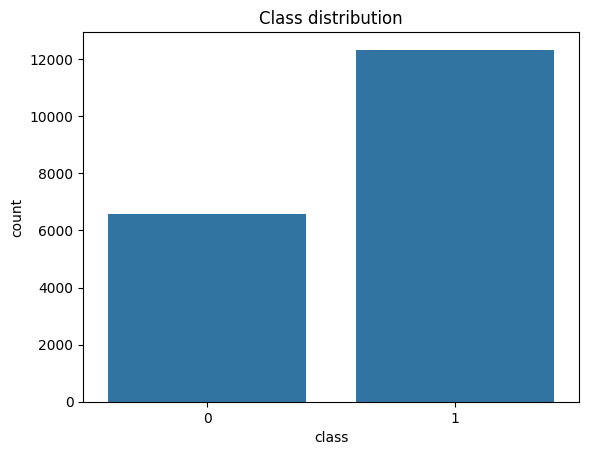

In [ ]:
sns.countplot(x="class", data=df)
plt.title("Class distribution")
plt.show()

Гистограммы признаков

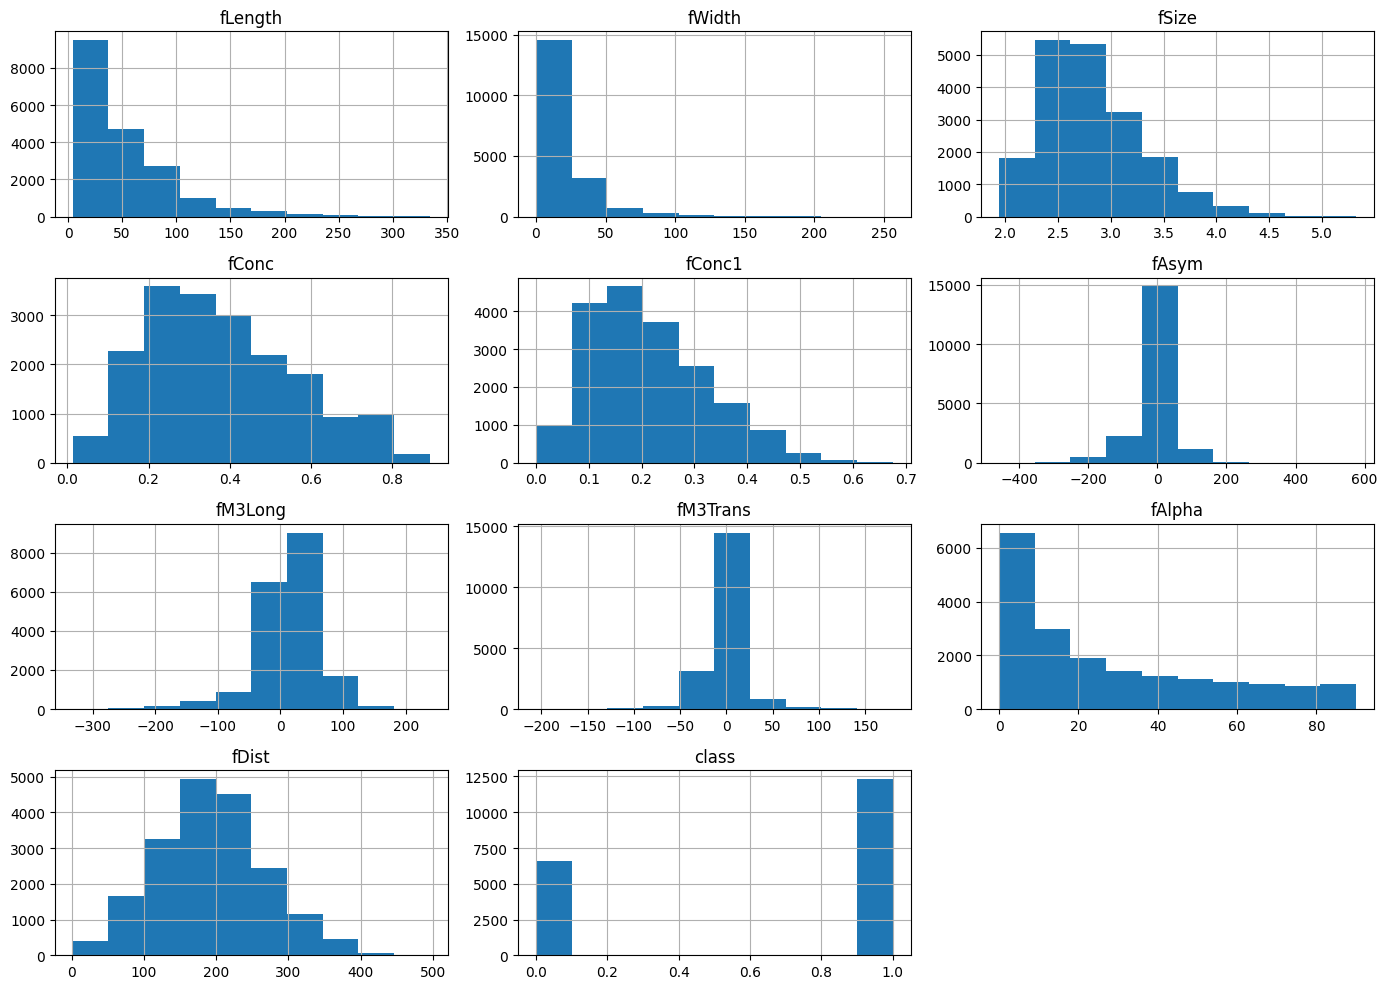

In [ ]:
df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

Корреляции

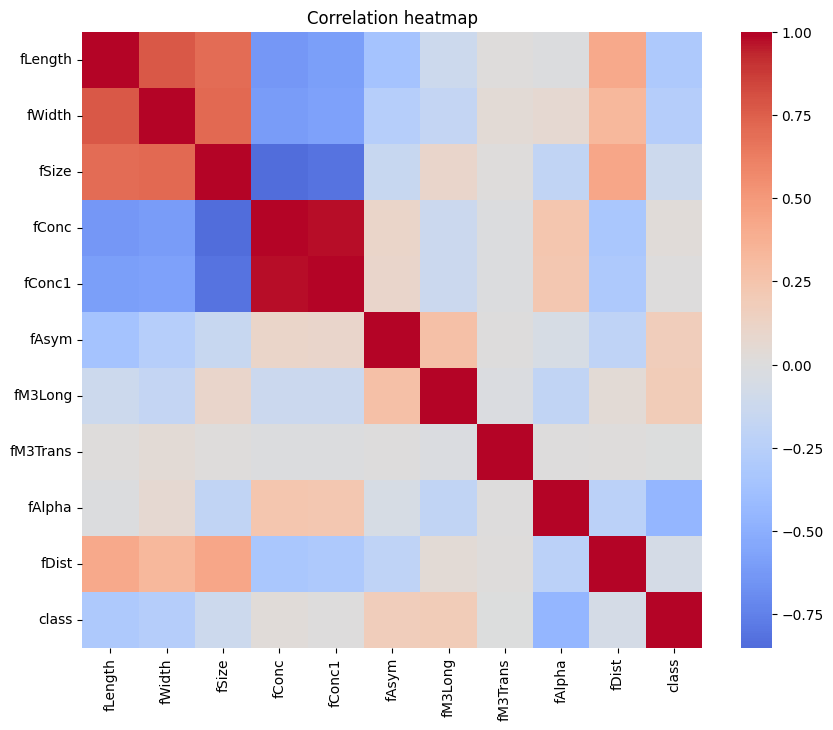

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

Boxplot

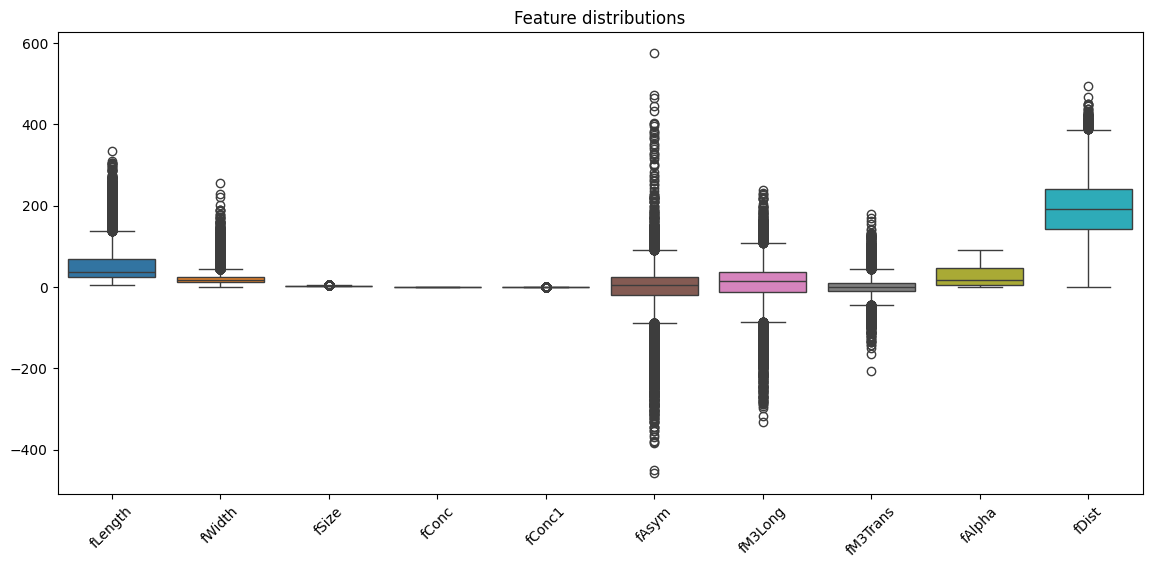

In [ ]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.drop(columns=["class"]))
plt.xticks(rotation=45)
plt.title("Feature distributions")
plt.show()

### Выводы по EDA

- Пропусков в данных нет  
- Были обнаружены дубликаты, которые были удалены  
- Признаки имеют разный масштаб  
- Наблюдается небольшая несбалансированность классов  

Блок 8. Разделение на train/val/test

In [ ]:
X = df.drop(columns=["class"])
y = df["class"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (11343, 10)
Validation: (3781, 10)
Test: (3781, 10)


Блок 9. Функция оценки модели

In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_proba)
    else:
        roc_auc = np.nan

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "f1": f1_score(y_val, y_pred),
        "roc_auc": roc_auc
    }

(выбор метрики)

В качестве основной метрики была выбрана ROC-AUC, поскольку задача является бинарной классификацией. ЭТА метрика позволяет оценить качество разделения классов при различных порогах классификации. Допом использовались Accuracy, Precision, Recall и F1-score для более полной оценки качества моделей.

## Выбор моделей

В качестве baseline выбрана Logistic Regression.

Также рассматриваются:
- KNN
- DecisionTree
- Random Forest

Это позволяет сравнить разные подходы к задаче классификации.

Блок 10. Обучение моделей

In [ ]:
models = [
    (
        "LogisticRegression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ])
    ),
    (
        "KNN",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ])
    ),
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=42)
    ),
    (
        "RandomForest",
        RandomForestClassifier(n_estimators=200, random_state=42)
    )
]

Блок 11. Таблица результатов

In [ ]:
results = []

for name, model in models:
    result = evaluate_model(model, X_train, y_train, X_val, y_val, name)
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
3,RandomForest,0.882229,0.889575,0.934307,0.911392,0.936481
1,KNN,0.827813,0.824203,0.933496,0.875452,0.870924
0,LogisticRegression,0.788644,0.797849,0.902676,0.847032,0.841055
2,DecisionTree,0.809411,0.854872,0.850365,0.852612,0.792148


Блок 12. Проверка лучшей модели на test

In [ ]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train_full, y_train_full)

y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))

Test Accuracy: 0.8885383806519453
Test Precision: 0.8896946564885496
Test Recall: 0.9452554744525548
Test F1: 0.9166338969720802
Test ROC-AUC: 0.9384023314991206


Блок 13. Вывод

## Вывод

Я загрузила и проанализировала датасет MAGIC Gamma Telescope.  
Пропусков в данных не оказалось, но были найдены дубликаты, которые я удалила.

После подготовки данных разделила их на обучающую, валидационную и тестовую выборки.

Далее обучила несколько моделей: Logistic Regression, KNN, Decision Tree и Random Forest.  
Сравнение проводилось по метрике ROC-AUC (основная), а также Accuracy и F1-score.

Лучший результат на валидации показала модель Random Forest, поэтому она была выбрана как финальная.  
На тестовой выборке модель также показала хорошие результаты (ROC-AUC ≈ 0.93).